In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/Users/kakulrajput/Documents/GItHub/DA-Retail-Profit-Leakage-Analysis/Kakul/python/Clean_superstore.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Sub-Category                                       Product Name     Sales  \
0    Bookcase

In [7]:
print(df["Sales"].sum())
print(df["Profit"].sum())
print(df["Profit Margin"].mean())

2297200.8603
286397.0217
0.12031392972104457


Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


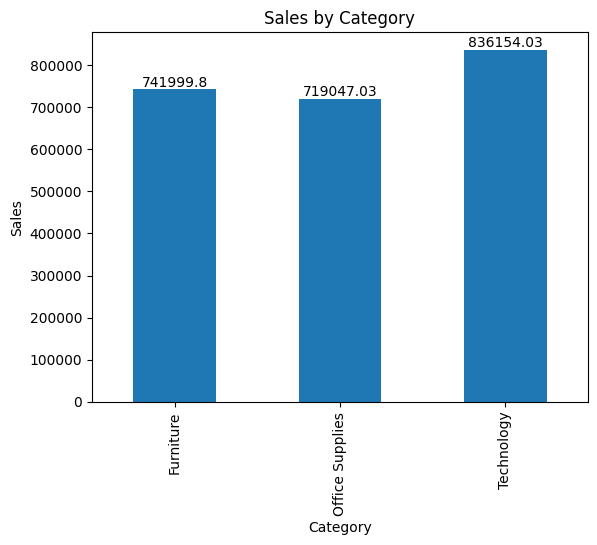

In [9]:
sales_category=df.groupby("Category")["Sales"].sum()
print(sales_category)
ax = sales_category.plot(kind="bar")
for i, v in enumerate(sales_category):
    plt.text(i, v, str(round(v,2)), ha="center", va="bottom")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


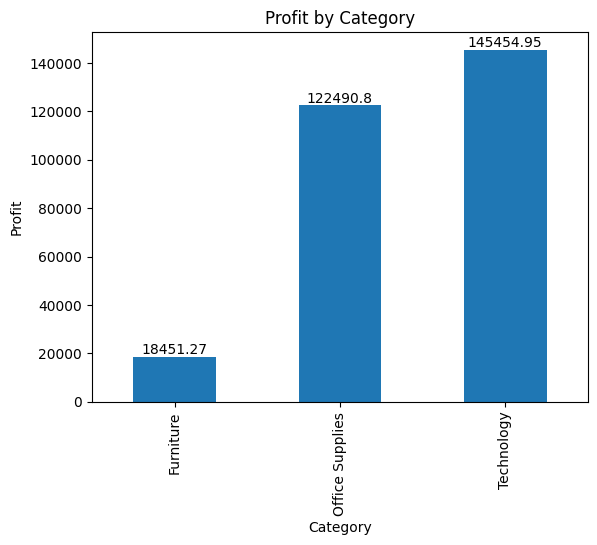

In [10]:
Profit_category = df.groupby("Category")["Profit"].sum()
print(Profit_category)


ax = Profit_category.plot(kind="bar")
for i, v in enumerate(Profit_category):
    plt.text(i, v, str(round(v,2)), ha="center", va="bottom")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6527.7870
Binders        30221.7633
Bookcases      -3472.5560
Chairs         26590.1663
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13059.1436
Labels          5546.2540
Machines        3384.7569
Paper          34053.5693
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64


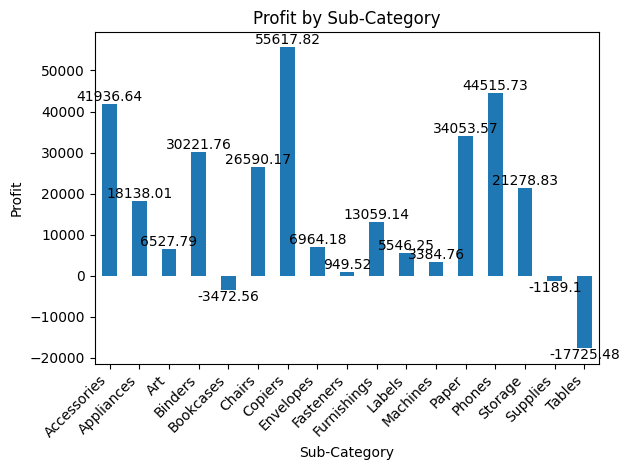

In [11]:
Profit_Sub_category = df.groupby("Sub-Category")["Profit"].sum()
print(Profit_Sub_category)

ax = Profit_Sub_category.plot(kind="bar")
for i, v in enumerate(Profit_Sub_category):
    va = "bottom" if v >= 0 else "top"
    plt.text(i, v, str(round(v, 2)), ha="center", va=va)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout() 
plt.show()

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


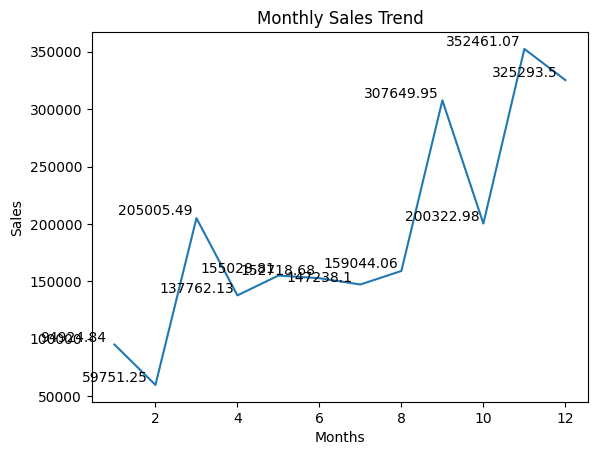

In [12]:
Monthly_Sales = df.groupby("Month")["Sales"].sum()
print(Monthly_Sales)

ax = Monthly_Sales.plot(kind="line")
for i, v in enumerate(Monthly_Sales):
    plt.text(i, v, str(round(v,2)), ha="center", va="bottom")
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


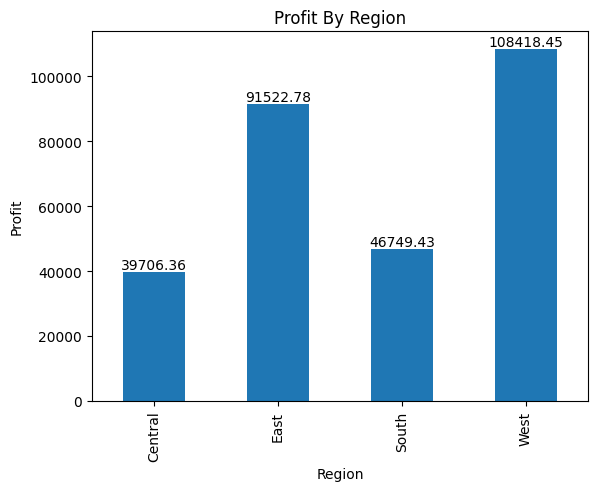

In [13]:
Profit_region = df.groupby("Region")["Profit"].sum()
print(Profit_region)

ax = Profit_region.plot(kind="bar")
for i, v in enumerate(Profit_region):
    plt.text(i, v, str(round(v,2)), ha="center", va="bottom")
plt.title("Profit By Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()


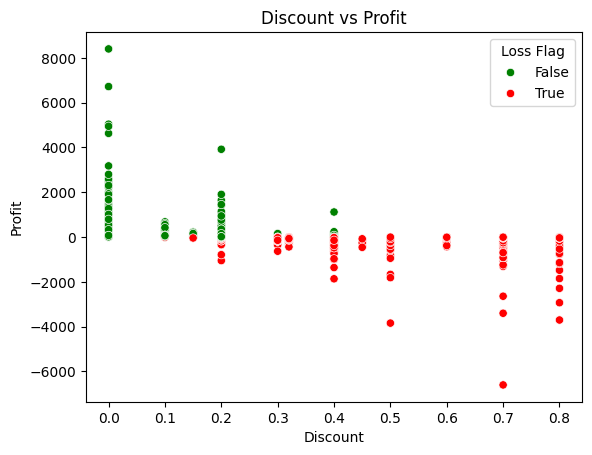

(1871, 25)
                                         Product Name      Sales     Profit
3       Bretford CR4500 Series Slim Rectangular Table   957.5775  -383.0310
14  Holmes Replacement Filter for HEPA Air Cleaner...    68.8100  -123.8580
15   Storex DuraTech Recycled Plastic Frosted Binders     2.5440    -3.8160
23                 Global Deluxe Stacking Chair, Gray    71.3720    -1.0196
27  Riverside Palais Royal Lawyers Bookcase, Royal...  3083.4300 -1665.0522


In [14]:
sns.scatterplot(x="Discount", y="Profit",
                hue="Loss Flag",
                palette={False:"green", True:"red"},
                data=df)

plt.title("Discount vs Profit")
plt.show()

#Loss making Orders
print(df[df["Profit"]<0].shape)

# Top loss products
print(df[df["Profit"]<0][["Product Name" , "Sales" , "Profit"]].head())

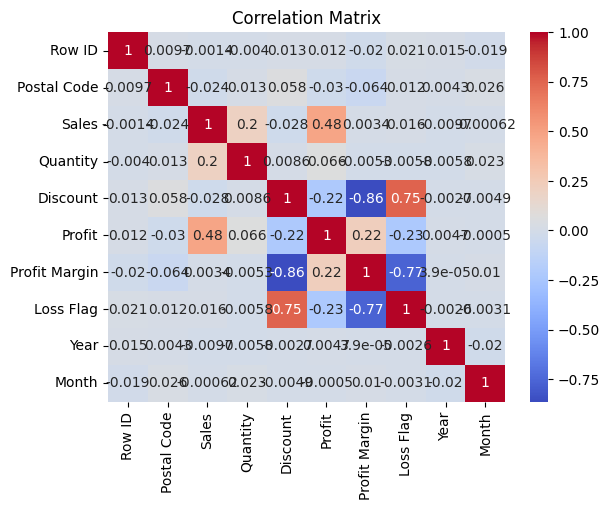

In [15]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

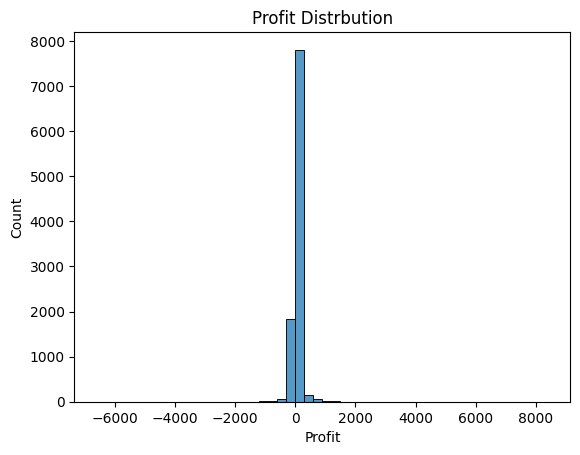

In [16]:
sns.histplot(df["Profit"] , bins=50)
plt.title("Profit Distrbution")
plt.show()

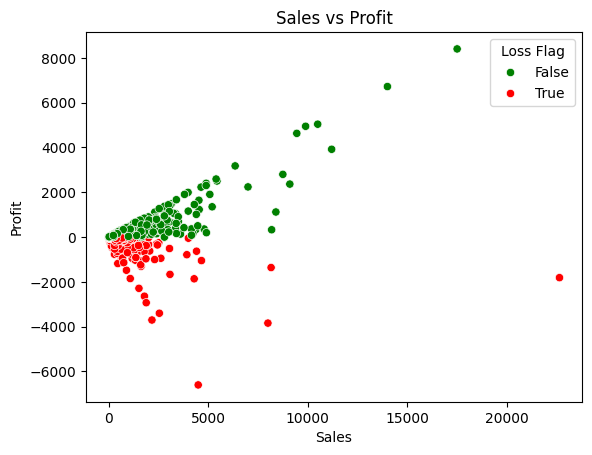

In [17]:
sns.scatterplot(x="Sales", y="Profit",
                 hue="Loss Flag",
                palette={False:"green", True:"red"},
                data=df)

plt.title("Sales vs Profit")
plt.show()

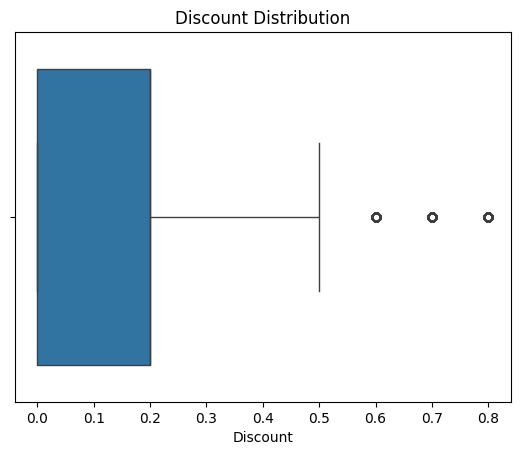

In [18]:
sns.boxplot(x="Discount" , data=df)
plt.title("Discount Distribution")
plt.show()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


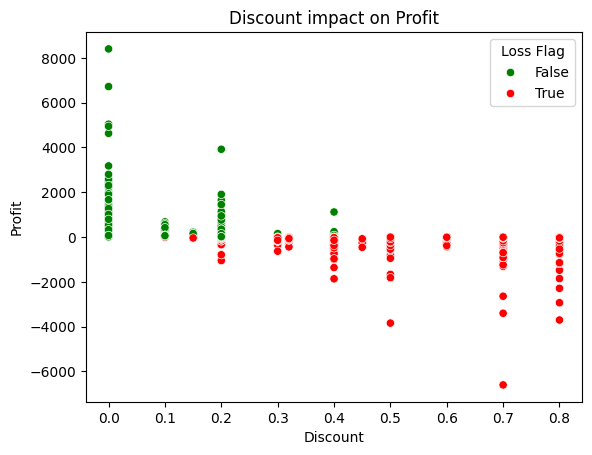

In [19]:
print(df.groupby("Discount")["Profit"].mean())
sns.scatterplot(x="Discount" , y="Profit" ,   hue="Loss Flag",
             palette={False:"green", True:"red"} , data=df)
plt.title("Discount impact on Profit")
plt.show()

In [20]:
loss_products = df[df["Profit"]<0]
print(loss_products.groupby("Sub-Category")["Profit"].sum().sort_values())

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64


In [21]:

print(df.groupby("Region")["Profit"].sum().sort_values())

Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64
